In [53]:
import numpy as np

def principal_sqrt(z):
    """
    Principal branch complex sqrt. numpy.sqrt already does principal branch,
    but we wrap it so it's explicit.
    """
    return np.sqrt(z)

def midplane_T1_asymptotic(
    m=1,
    beta_ex=1e-4,          # = Omega * t_ex  (gas-radiation exchange parameter)
    tau_max=100.0,         # optical depth at midplane
    beta=1.0,              # grazing-incidence attenuation depth-scale in tau
    Theta_star=1.0,        # forcing amplitude in Theta1(tau)=Theta_star*exp(-tau/beta)
    T0=100.0,              # background temperature (K) used only in scaling of E->T
    a_rad=7.5657e-15,      # radiation constant a [erg cm^-3 K^-4]
):
    """
    Implements tau_max/beta >> 1 asymptotic solution.

    Returns:
      k, A, B, E_mid, T_mid, amp_T_mid, phase_T_mid
    """
    i = 1j

    # k^2 and k
    k2 = 3.0 * (i*m*beta_ex) / (1.0 + i*m*beta_ex)
    k  = principal_sqrt(k2)

    # Forcing profile and source amplitude:
    # Theta1(tau)=Theta_star exp(-tau/beta)
    # S(tau)=S_star exp(-tau/beta), with:
    # S_star = 12 a T0^3 Theta_star * beta_ex/(1+i m beta_ex)
    S_star = 12.0 * a_rad * (T0**3) * Theta_star * (beta_ex / (1.0 + i*m*beta_ex))

    # Particular solution coefficient A
    denom = (beta**(-2) - k2)
    A = -S_star / denom

    # B coefficient (psi=1/sqrt(3) -> 3psi = sqrt(3))
    sqrt3 = np.sqrt(3.0)
    B = (A / k) * (sqrt3 + 1.0/beta)

    # Asymptotic midplane E1(tau_max): drop exp(-tau_max/beta) terms
    kt = k * tau_max
    E_mid = -B / (np.cosh(kt) * (np.tanh(kt) + sqrt3 / k))

    # Midplane temperature perturbation (since Theta1(tau_max) ~ 0)
    T_mid = (E_mid / (4.0 * a_rad * (T0**3))) * (1.0 / (1.0 + i*m*beta_ex))

    amp_T_mid = np.abs(T_mid)
    phase_T_mid = np.angle(T_mid)  # radians in (-pi, pi]

    return {
        "k2": k2,
        "k": k,
        "A": A,
        "B": B,
        "E_mid": E_mid,
        "T_mid": T_mid,
        "amp_T_mid": amp_T_mid,
        "phase_T_mid_rad": phase_T_mid,
    }

def phase_shift_surface_to_midplane(
    m=1,
    beta_ex=1e-4,
    tau_max=100.0,
    beta=1.0,
    Theta_star=1.0,
    T0=100.0,
    a_rad=7.5657e-15,
):
    """
    Optional: compute phase shift Δφ = arg(T_mid) - arg(T_surface)
    using the SAME asymptotic structure for E(0) implied by the surface BC.

    At tau=0:
      E(0) = C + A
      E'(0) = kD - A/beta
      and BC: E'(0) = sqrt(3) E(0)

    Under tau_max/beta>>1, we used:
      D ≈ -C tanh(k tau_max)

    Solve for C and then compute T_surface using full relation (includes Theta1 at surface).
    """
    i = 1j
    sqrt3 = np.sqrt(3.0)

    k2 = 3.0 * (i*m*beta_ex) / (1.0 + i*m*beta_ex)
    k  = np.sqrt(k2)

    S_star = 12.0 * a_rad * (T0**3) * Theta_star * (beta_ex / (1.0 + i*m*beta_ex))
    A = -S_star / (beta**(-2) - k2)

    kt = k * tau_max
    tanh_kt = np.tanh(kt)

    # Use D = -C tanh(k tau_max) and surface BC:
    # kD - A/beta = sqrt3 (C + A)
    # k(-C tanh_kt) - A/beta = sqrt3 C + sqrt3 A
    # C(-k tanh_kt - sqrt3) = A(1/beta + sqrt3)
    C = -A * (1.0/beta + sqrt3) / (k * tanh_kt + sqrt3)

    # Now compute E at surface and midplane
    D = -C * tanh_kt
    E0 = C + A  # at tau=0 (since exp(0)=1)
    # midplane from earlier asymptotic expression:
    E_mid = -( (A/k)*(sqrt3+1.0/beta) ) / (np.cosh(kt) * (np.tanh(kt) + sqrt3/k))

    # Temperature perturbation formula:
    # T1 = [Theta1 + E/(4 a T0^3 beta_ex)] / (im + beta_ex^{-1})
    # with Theta1(0)=Theta_star
    denom = (i*m + 1.0/beta_ex)
    T_surface = (Theta_star + E0/(4.0*a_rad*(T0**3)*beta_ex)) / denom

    # Midplane uses Theta1 ~ 0:
    T_mid = (E_mid/(4.0*a_rad*(T0**3)*beta_ex)) / denom

    dphi = np.angle(T_mid) - np.angle(T_surface)
    # wrap to (-pi, pi]
    dphi = (dphi + np.pi) % (2*np.pi) - np.pi

    return {
        "T_surface": T_surface,
        "T_mid": T_mid,
        "amp_surface": np.abs(T_surface),
        "amp_mid": np.abs(T_mid),
        "phase_surface_rad": np.angle(T_surface),
        "phase_mid_rad": np.angle(T_mid),
        "dphi_mid_minus_surface_rad": dphi,
    }

# ---- Example usage ----
if __name__ == "__main__":
    out = midplane_T1_asymptotic(m=1, beta_ex=5e-4, tau_max=32.0, beta=0.05, Theta_star=1.0, T0=24.0)
    print("k =", out["k"])
    print("|T_mid| =", out["amp_T_mid"])
    print("arg(T_mid) [rad] =", out["phase_T_mid_rad"])

    out2 = phase_shift_surface_to_midplane(m=1, beta_ex=5e-4, tau_max=32.0, beta=0.05, Theta_star=1.0, T0=24.0)
    print("Δphi (mid - surf) [rad] =", out2["dphi_mid_minus_surface_rad"])
    print("amp ratio mid/surf =", out2["amp_mid"]/out2["amp_surface"])


k = (0.02739297183870833+0.027379278776910237j)
|T_mid| = 3.940449382542909e-05
arg(T_mid) [rad] = -0.7242299810215477
Δphi (mid - surf) [rad] = -0.7218726446472727
amp ratio mid/surf = 0.07259466019787807


In [90]:
np.sqrt(5e-4) * 64

np.float64(1.4310835055998654)

[]

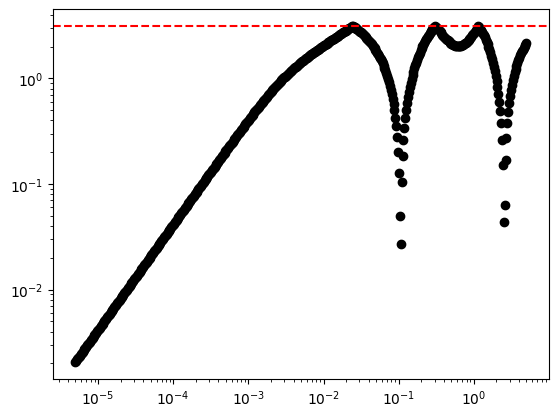

In [91]:
for beta_ex_factor in np.logspace(-2, 4, num=500):  # e.g., factors of 1, 3.16, 10, 31.6, 100
    out = midplane_T1_asymptotic(m=1, beta_ex=5e-4*beta_ex_factor, tau_max=32.0/2, beta=0.05, Theta_star=1.0, T0=24.0)
    plt.plot(beta_ex_factor * 5e-4, np.abs(np.angle(out["E_mid"])), color='k',marker='o', label=f'beta_ex_factor={beta_ex_factor}')
plt.axhline(np.pi, color='r', linestyle='--')
plt.loglog()

[]

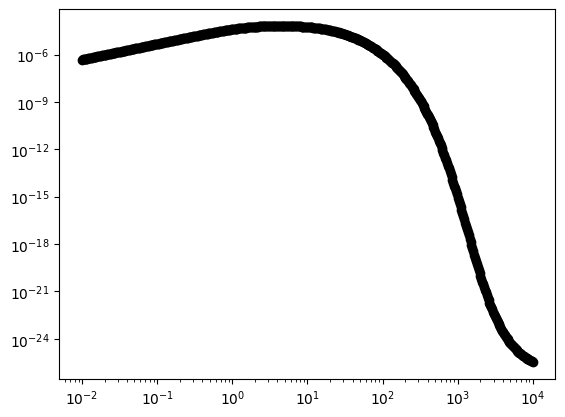

In [98]:
for beta_ex_factor in np.logspace(-2, 4, num=500):  # e.g., factors of 1, 3.16, 10, 31.6, 100
    out = midplane_T1_asymptotic(m=1, beta_ex=5e-4*beta_ex_factor, tau_max=32.0, beta=0.05, Theta_star=1.0, T0=24.0)
    plt.plot(beta_ex_factor , out["amp_T_mid"], color='k',marker='o', label=f'beta_ex_factor={beta_ex_factor}')
plt.loglog()

[]

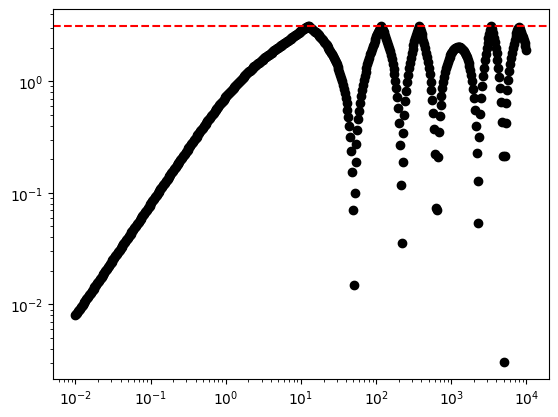

In [101]:
for beta_ex_factor in np.logspace(-2, 4, num=500):  # e.g., factors of 1, 3.16, 10, 31.6, 100
    out = midplane_T1_asymptotic(m=1, beta_ex=5e-4*beta_ex_factor, tau_max=32.0, beta=0.05, Theta_star=1.0, T0=24.0)
    plt.plot(beta_ex_factor , np.abs(-out["phase_T_mid_rad"]), color='k',marker='o', label=f'beta_ex_factor={beta_ex_factor}')
plt.axhline(np.pi, color='r', linestyle='--')
plt.loglog()

In [ ]:
out2 = phase_shift_surface_to_midplane(m=1, beta_ex=5e-4, tau_max=32.0, beta=0.05, Theta_star=1.0, T0=24.0)
print("Δphi (mid - surf) [rad] =", out2["dphi_mid_minus_surface_rad"])

Δphi (mid - surf) [rad] = -0.7218726446472727


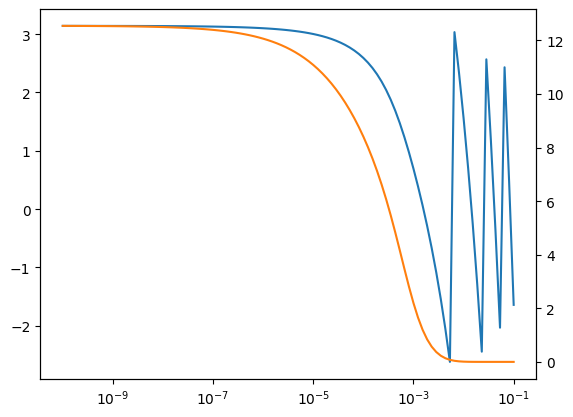

In [40]:
beta_ex = np.logspace(-10, -1, 100)
k = np.sqrt(3 *(1j*beta_ex)/(1.+1j*beta_ex))
r = np.exp(-2.*k*32.0)
E1 = 2.*(np.sqrt(3) + 20) * np.exp(-k*32.0) / (k*(r-1) - np.sqrt(3)*(r+1)) * np.exp(-k*32.0)

import matplotlib.pyplot as plt
plt.plot(beta_ex, np.angle(E1))
plt.semilogx()
plt.twinx()
plt.plot(beta_ex, np.abs(E1), color='C1')

In [30]:
np.angle(E1)

np.float64(0.9923365917390673)

In [22]:
(k*(r-1) - np.sqrt(3)*(r+1)) 

np.complex128(-1.8411115338255701+0.41001724019918306j)

In [19]:
np.exp(-k*32.0)

np.complex128(0.39476318581962017-0.31839530952421374j)

In [21]:
np.angle(np.exp(-k*32.0))

np.float64(-0.6787206636580643)